# Merge and Export Machine Learning Dataset
This notebook gathers all the pre-calculated features from the other scripts (OSM POIs, Land Use percentages, and Terrain Slope) and merges them into one single comprehensive `.csv` table that will be fed to the Machine Learning models.

## Note: Data Requirements

In [23]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datatsets

In [24]:
# Define file paths (UNCOMMENT AND ADJUST ONCE YOU HAVE EXPORTED THE DATA)

path_osm_roads = "data/osm_roads_features.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points = "data/osm_points_features.csv"

df_osm_roads = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points = pd.read_csv(path_osm_points)

print("Data loaded successfully.")

Data loaded successfully.


In [25]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_length,road_category,dist_to_main
0,13845167536_847716886_0,55,55,50,401.483629,5,258.681126
1,21638869_30343583_0,55,50,50,90.289544,5,429.190460
2,21638869_242318729_0,55,55,50,15.055894,4,512.333789
3,21638869_30343672_0,60,60,55,15.404960,4,516.423077
4,3055187877_431100338_0,60,60,55,46.142160,5,214.041852


In [26]:
df_momepy_roads.head()

,road_id,width,betw_centrality,clos_centrality
0,21638845_885308258_0,43.025602,0.000896,0.000147
1,21638845_13175411896_0,26.114886,0.002015,0.000154
2,13175411896_21638845_0,26.600754,0.002015,0.000154
3,885308314_21638845_0,50.000000,0.000896,0.000147
4,885308258_885308166_0,38.147174,0.000672,0.000145


## Merge dataframes

In [27]:
# Function to merge feature DataFrame with base DataFrame

def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    # Drop target columns
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    
    # Drop duplicate columns (except road_id)
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    
    # Ensure road_id exists and is consistent
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    
    return base_df.merge(clean_df, on='road_id', how='left')

In [28]:

ml_dataset = df_osm_roads.copy()

# Columns to remove to avoid repetition
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

# Check road_id types before merging
print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points', df_osm_points),
    ('Momepy Roads', df_momepy_roads),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str


,road_id,noise_day,noise_evening,noise_night,road_length,road_category,dist_to_main,signals,transport,pois,width,betw_centrality,clos_centrality
0,13845167536_847716886_0,55,55,50,401.483629,5,258.681126,0.249061,2.490612,0.747184,16.759462,0.004427,0.000215
1,21638869_30343583_0,55,50,50,90.289544,5,429.190460,1.106183,3.318548,25.000000,7.972898,0.000021,0.000167
2,21638869_242318729_0,55,55,50,15.055894,4,512.333789,6.654893,10.000000,25.000000,17.913847,0.001011,0.000166
3,21638869_30343672_0,60,60,55,15.404960,4,516.423077,6.504094,10.000000,25.000000,18.216613,0.002190,0.000166
4,3055187877_431100338_0,60,60,55,46.142160,5,214.041852,2.170191,4.340383,2.170191,16.532075,0.006955,0.000226
5,3109574424_3109574426_0,55,50,45,75.757316,6,38.702252,1.320651,3.961954,21.130422,14.674738,0.000224,0.000202
6,21638867_30343414_0,65,60,55,91.037745,5,382.085637,1.097089,5.485447,25.000000,6.935241,0.000681,0.000169
7,21638878_242317164_0,40,40,40,14.636801,5,420.707644,6.845361,10.000000,25.000000,7.142476,0.001946,0.000168
8,21638877_30343573_0,50,50,45,59.188192,5,341.179073,1.687456,3.374911,25.000000,6.850539,0.000002,0.000170
9,21638877_1636238506_0,50,50,45,14.928692,5,396.819559,6.711698,10.000000,25.000000,7.268418,0.002434,0.000169


<class 'pandas.DataFrame'>
RangeIndex: 11669 entries, 0 to 11668
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          11669 non-null  str    
 1   noise_day        11669 non-null  int64  
 2   noise_evening    11669 non-null  int64  
 3   noise_night      11669 non-null  int64  
 4   road_length      11669 non-null  float64
 5   road_category    11669 non-null  int64  
 6   dist_to_main     11669 non-null  float64
 7   signals          11669 non-null  float64
 8   transport        11669 non-null  float64
 9   pois             11669 non-null  float64
 10  width            11669 non-null  float64
 11  betw_centrality  11669 non-null  float64
 12  clos_centrality  11669 non-null  float64
dtypes: float64(8), int64(4), str(1)
memory usage: 1.2 MB
Final dataset shape: (11669, 13)


## Noise distribution

     Day  Evening   Night
40   247      355   979.0
45   409      592  1469.0
50  1102     1482  2588.0
55  2323     2629  3256.0
60  3078     3294  2751.0
65  3111     2693   626.0
70  1399      624     NaN


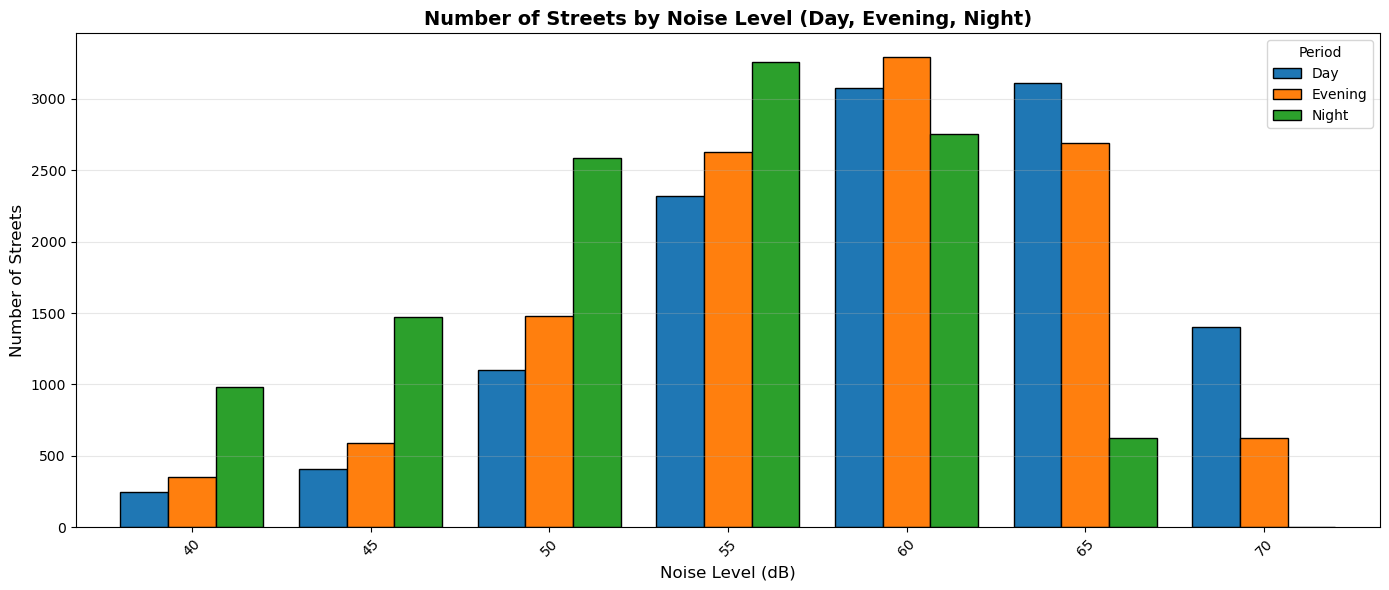

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_day = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night = ml_dataset.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

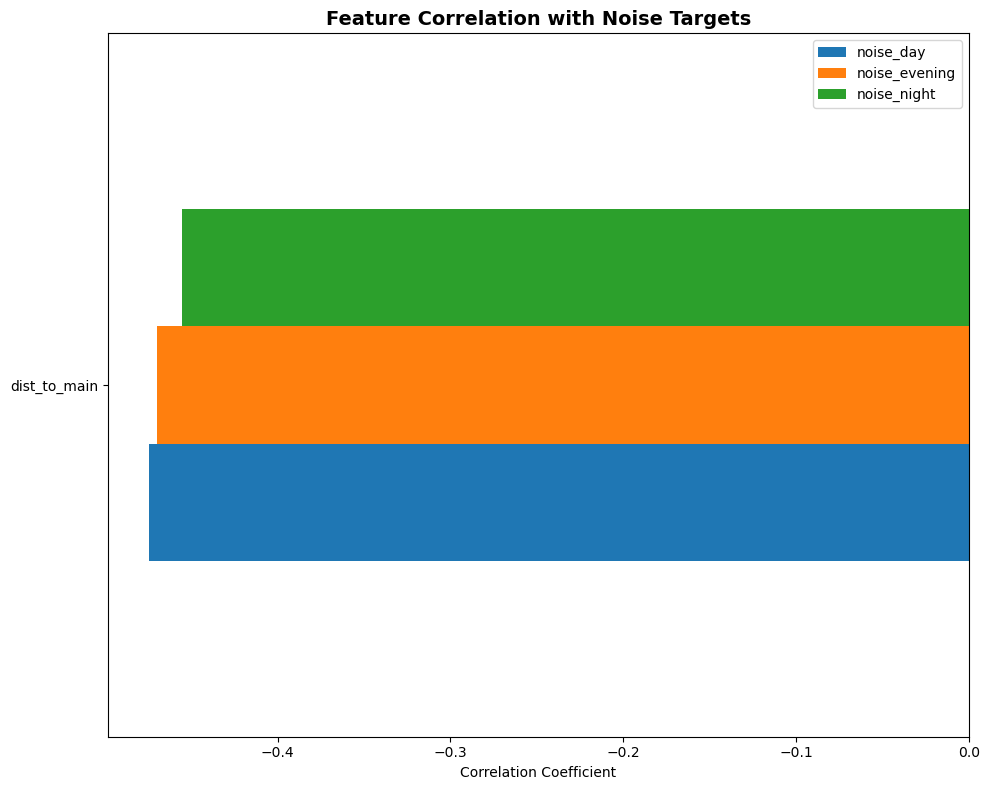

              noise_day  noise_evening  noise_night
dist_to_main  -0.474534      -0.469841    -0.455065


In [36]:
# Extract correlations with noise predictions
dataset_filtered = ml_dataset[['noise_day', 'noise_evening', 'noise_night','dist_to_main']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export to CSV
Finally, we dump out the master table into a standard format readable by `scikit-learn` in the next phase!

In [30]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_ml_dataset.csv


## Subsample

In [31]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 5000

# Calculate the proportion of each noise value in the original data
proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
40    0.021204
45    0.035007
50    0.094419
55    0.199040
60    0.263853
65    0.266653
70    0.119824
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
40            247    106
45            409    175
50           1102    472
55           2323    995
60           3078   1319
65           3111   1333
70           1399    599


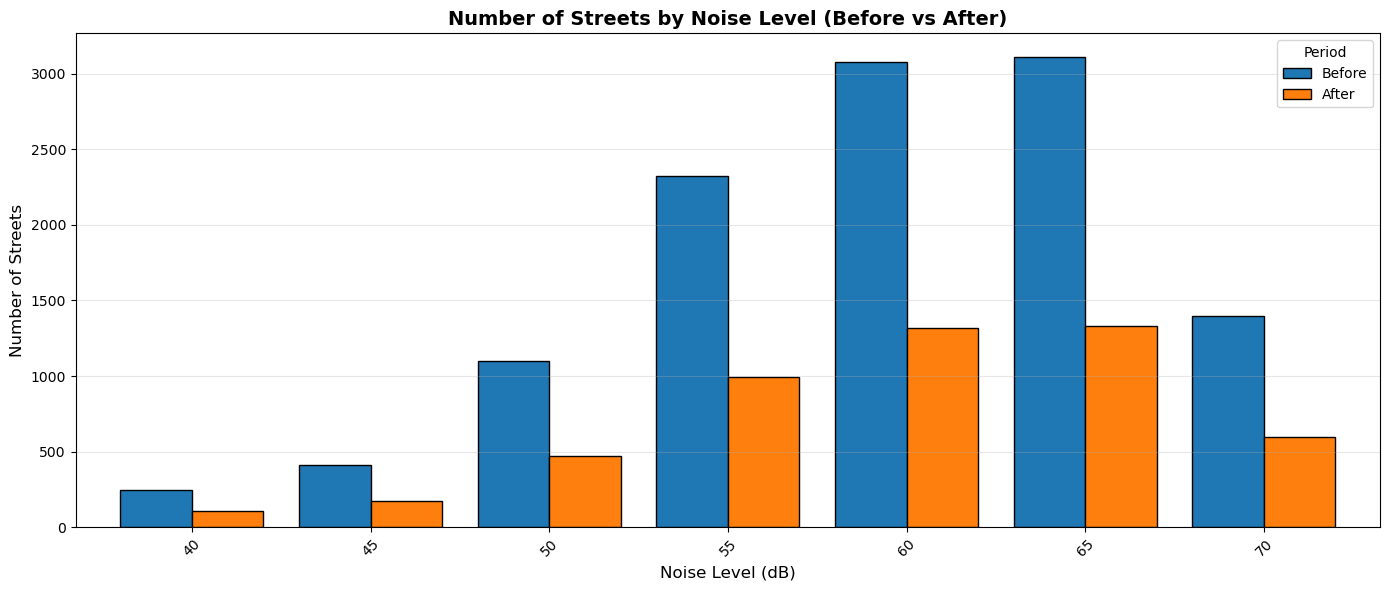

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_before = ml_dataset.groupby('noise_day').size()
counts_after = subsampled.groupby('noise_day').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Before': counts_before,
    'After': counts_after
})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

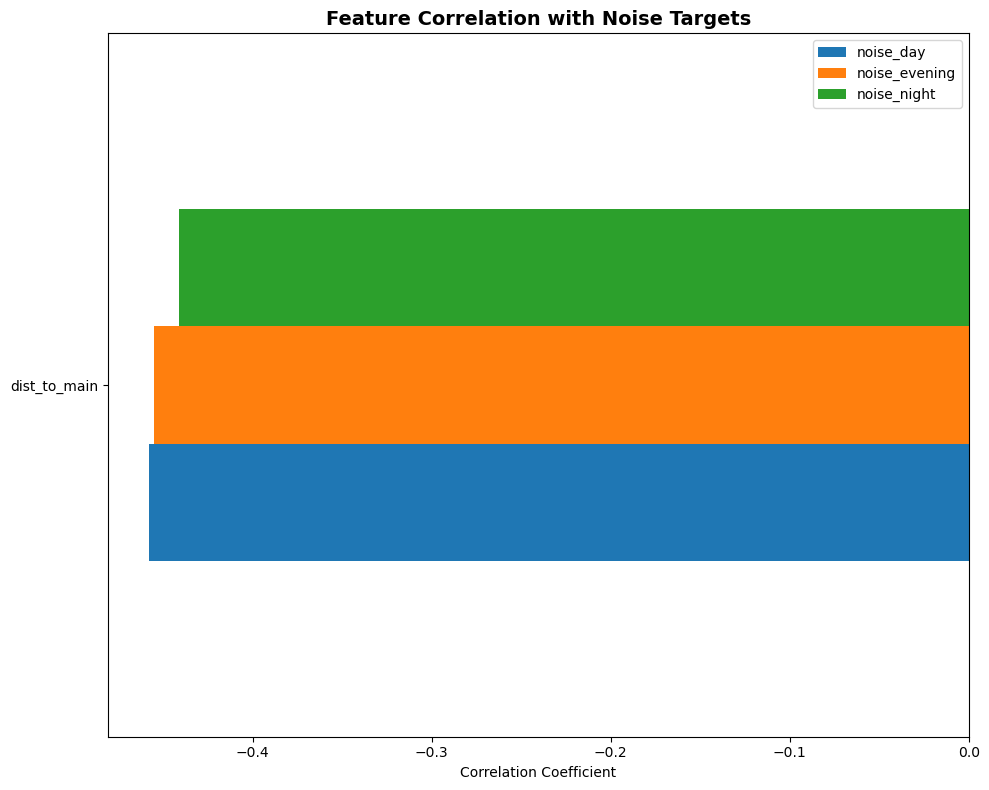

              noise_day  noise_evening  noise_night
dist_to_main   -0.45791      -0.455178     -0.44091


In [35]:
# Extract correlations with noise predictions
dataset_filtered = subsampled[['noise_day', 'noise_evening', 'noise_night','dist_to_main']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export CSV

In [33]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_ml_subsample.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_ml_subsample.csv
